# **Analyse des ventes d une librairie avec python**

## Importation des librairies

In [2]:
import pandas as pd

In [3]:
import plotly.express as px 

In [4]:
import seaborn as sns

In [5]:
import matplotlib.pyplot as plt

In [6]:
import numpy as np

In [7]:
import scipy.stats as stats

## Chargement des fichiers

In [8]:
#Importation du fichier product.xlsx
df_products = pd.read_csv("products.csv",delimiter=";")
#Importation du fichier erp.xlsx
df_transactions = pd.read_csv("Transactions.csv", delimiter=";", low_memory=False)

#importation du fichier liaison.xlsx
df_customers=pd.read_csv("customers.csv",delimiter=";")

## Analyse exploratoire des différents fichiers

## Fichier Product

In [9]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_products.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_products.shape[1]))
#La nature des données dans chacune des colonnes
print(df_products.dtypes)

Le tableau comporte 3286 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)
id_prod     object
price      float64
categ        int64
dtype: object


## Fichier Transactions

In [10]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_transactions.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_transactions.shape[1]))
#La nature des données dans chacune des colonnes
print(df_transactions.dtypes)

Le tableau comporte 1048575 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)
id_prod       object
date          object
session_id    object
client_id     object
dtype: object


## Fichier customers

In [11]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_customers.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_customers.shape[1]))
#La nature des données dans chacune des colonnes
print(df_customers.dtypes)

Le tableau comporte 8621 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)
client_id    object
sex          object
birth         int64
dtype: object


In [12]:
# Affichage des 5 premières lignes
print("Table product\n")
print(df_products.head)
print("Table customers\n")
print(df_customers.head)
print("Table transactions\n")
print(df_transactions.head)
#Faire une courbe pour voir l'evolution

Table product

<bound method NDFrame.head of      id_prod   price  categ
0     0_1421   19.99      0
1     0_1368    5.13      0
2      0_731   17.99      0
3      1_587    4.99      1
4     0_1507    3.99      0
...      ...     ...    ...
3281    2_23  115.99      2
3282   0_146   17.14      0
3283   0_802   11.22      0
3284   1_140   38.56      1
3285  0_1920   25.16      0

[3286 rows x 3 columns]>
Table customers

<bound method NDFrame.head of      client_id sex  birth
0       c_4410   f   1967
1       c_7839   f   1975
2       c_1699   f   1984
3       c_5961   f   1962
4       c_5320   m   1943
...        ...  ..    ...
8616    c_7920   m   1956
8617    c_7403   f   1970
8618    c_5119   m   1974
8619    c_5643   f   1968
8620      c_84   f   1982

[8621 rows x 3 columns]>
Table transactions

<bound method NDFrame.head of         id_prod                        date session_id client_id
0        0_1259  2021-03-01 00:01:07.843138        s_1     c_329
1        0_1390  2021-03-01 

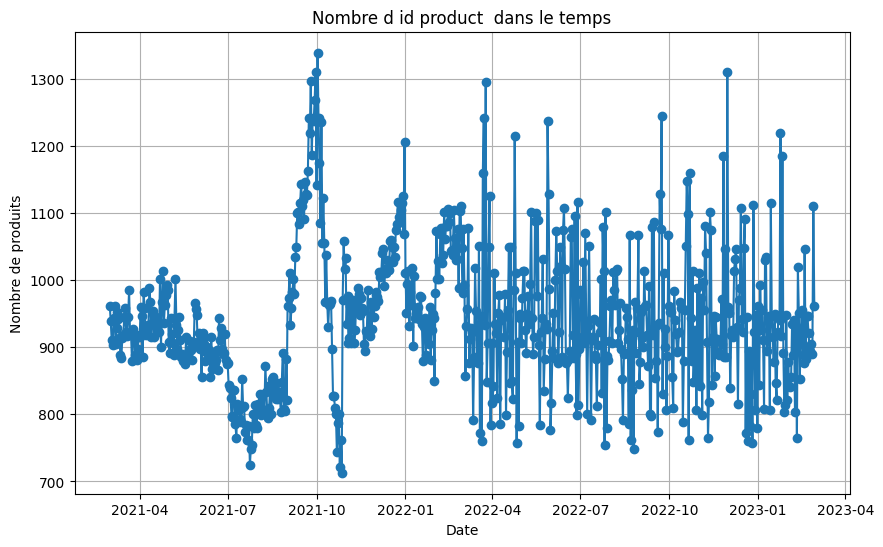

In [13]:
df_transactions['date'] = pd.to_datetime(df_transactions['date'])
df_grouped = df_transactions.groupby(df_transactions['date'].dt.date).size().reset_index(name='count')
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df_grouped['date'], df_grouped['count'], marker='o')
plt.xlabel('Date')
plt.ylabel('Nombre de produits')
plt.title('Nombre d id product  dans le temps')
plt.grid(True)
plt.show()


### Doublons dans les clés ?

In [14]:
# Verification des doublons id_prod de la table product

verif_doublons_id_prod=df_products[df_products['id_prod'].duplicated()]
print("Table produits :",verif_doublons_id_prod)
 #Verification des doublons id_prod de la table customers
verif_doublons_client_id=df_customers[df_customers['client_id'].duplicated()]
print("Table customers :",verif_doublons_client_id)


Table produits : Empty DataFrame
Columns: [id_prod, price, categ]
Index: []
Table customers : Empty DataFrame
Columns: [client_id, sex, birth]
Index: []


## Fusion des fichiers

In [15]:
transaction_customer = pd.merge(df_transactions,df_customers)
print(transaction_customer)
transaction_products=pd.merge(df_transactions,df_products)
print(transaction_products)
df = pd.merge(transaction_customer, transaction_products, on=['id_prod', 'date', 'session_id', 'client_id'])
print(df)

       id_prod                       date session_id client_id sex  birth
0       0_1259 2021-03-01 00:01:07.843138        s_1     c_329   f   1967
1       0_1390 2021-03-01 00:02:26.047414        s_2     c_664   m   1960
2       0_1352 2021-03-01 00:02:38.311413        s_3     c_580   m   1988
3       0_1458 2021-03-01 00:04:54.559692        s_4    c_7912   f   1989
4       0_1358 2021-03-01 00:05:18.801198        s_5    c_2033   f   1956
...        ...                        ...        ...       ...  ..    ...
687529   1_508 2023-02-28 23:49:03.148402   s_348444    c_3573   f   1996
687530    2_37 2023-02-28 23:51:29.318531   s_348445      c_50   f   1994
687531   1_695 2023-02-28 23:53:18.929676   s_348446     c_488   f   1985
687532  0_1547 2023-02-28 23:58:00.107815   s_348447    c_4848   m   1953
687533  0_1398 2023-02-28 23:58:30.792755   s_348435    c_3575   f   1981

[687534 rows x 6 columns]
       id_prod                       date session_id client_id  price  categ
0       

### Le chiffre d'affaire avec la moyenne mobile

#### La moyenne mobile est une moyenne arithmétique calculée sur une fenêtre glissante, elle permet de lisser les données pour voir les tendances générales et de réduire les fluctuations aléatoires

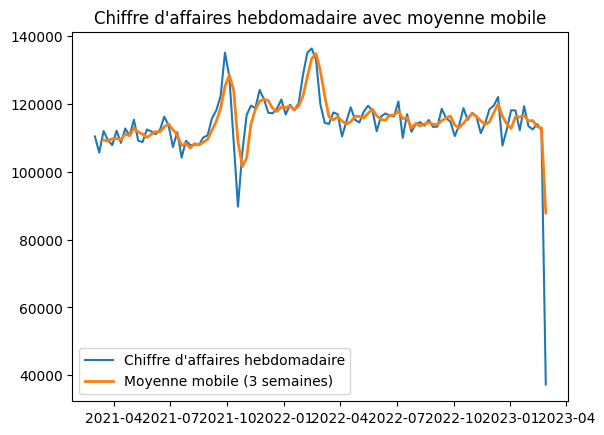

In [16]:
# Grouper par semaine
ca_hebdomadaire = transaction_products.groupby(transaction_products['date'].dt.to_period('W'))['price'].sum()

# Convertir l'index en timestamp pour la moyenne mobile
ca_hebdomadaire.index = ca_hebdomadaire.index.to_timestamp()

# Calculer la moyenne mobile sur 3 semaines
ca_moyenne_mobile = ca_hebdomadaire.rolling(window=3).mean()

import matplotlib.pyplot as plt
plt.plot(ca_hebdomadaire, label='Chiffre d\'affaires hebdomadaire')
plt.plot(ca_moyenne_mobile, label='Moyenne mobile (3 semaines)', linewidth=2)
plt.title('Chiffre d\'affaires hebdomadaire avec moyenne mobile')
plt.legend()
plt.show()


In [17]:
# Vérification du type
print(transaction_products['price'].dtype)

# Vérification des valeurs
print(transaction_products['price'].head())

# Vérification des valeurs nulles
print(transaction_products['price'].isnull().sum())

# Conversion si nécessaire
transaction_products['price'] = pd.to_numeric(transaction_products['price'], errors='coerce')

# Vérification après conversion
print(transaction_products['price'].describe())


float64
0    11.99
1    19.37
2     4.50
3     6.55
4    16.49
Name: price, dtype: float64
0
count    687534.000000
mean         17.493918
std          18.238337
min           0.620000
25%           8.990000
50%          13.990000
75%          19.080000
max         300.000000
Name: price, dtype: float64


### Le chiffre d'affaire par catégorie


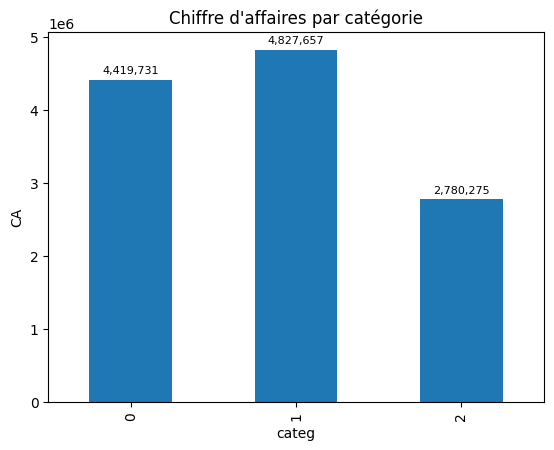

In [18]:

ca_par_categorie = transaction_products.groupby('categ')['price'].sum()

ax = ca_par_categorie.plot(kind='bar', title='Chiffre d\'affaires par catégorie')
plt.ylabel('CA')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,.0f}', 
                (p.get_x() + p.get_width() / 2., height),  # position au centre de la barre
                ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 3),
                textcoords='offset points')

plt.show()


### Nombre de clients par mois


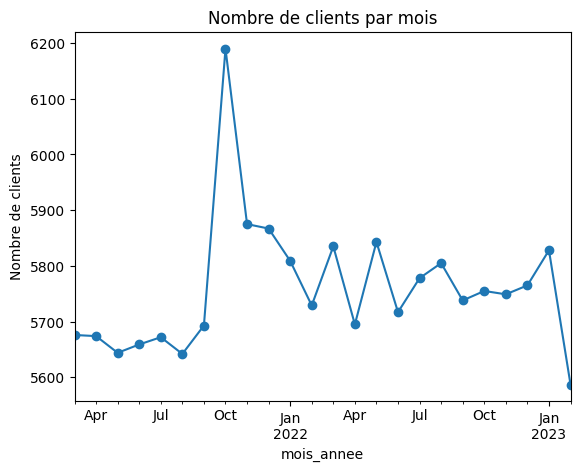

In [19]:
# Convertir la date en datetime

transaction_customer['date'] = pd.to_datetime(transaction_customer['date'])


transaction_customer['mois_annee'] = transaction_customer['date'].dt.to_period('M')

# Nombre de clients uniques par mois
clients_par_mois = transaction_customer.groupby('mois_annee')['client_id'].nunique() #.nunique compte le nombre de clients distinct

# Graphique
clients_par_mois.plot(kind='line', marker='o', title='Nombre de clients par mois')
plt.ylabel('Nombre de clients')
plt.show()


#### Nombre de transactions

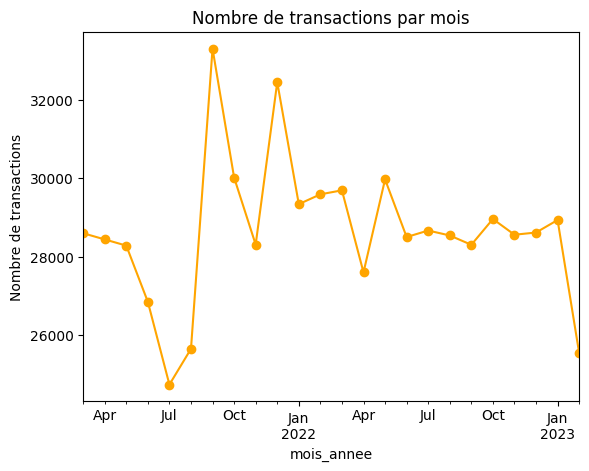

In [20]:

df_transactions['date'] = pd.to_datetime(df_transactions['date'])

df_transactions['mois_annee'] = df_transactions['date'].dt.to_period('M')

transactions_par_mois = df_transactions.groupby('mois_annee').size()

transactions_par_mois.plot(kind='line', marker='o', color='orange', title='Nombre de transactions par mois')
plt.ylabel('Nombre de transactions')
plt.show()


#### Nombre de produits vendus

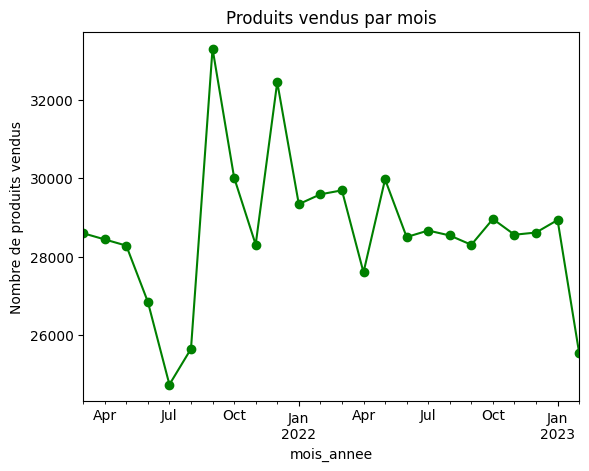

In [21]:
#En sachant que 1 produit correspond à une transaction celà revient à montrer le nombre de transaction
produits_vendus = df_transactions.groupby('mois_annee')['id_prod'].count()
# Graphique
produits_vendus.plot(kind='line', marker='o', color='green', title='Produits vendus par mois')
plt.ylabel('Nombre de produits vendus')
plt.show()



### Les TOPs

#### Top des 10 produits les plus achetés

In [22]:

top_products = transaction_customer.groupby('id_prod').size().reset_index(name='total_achats')

top_products = top_products.sort_values(by='total_achats', ascending=False)

top_10_products = top_products.head(10)

top_10_products = top_10_products.merge(df_products, on='id_prod', how='left')

print(top_10_products)


  id_prod  total_achats  price  categ
0   1_369          2340  23.99      1
1   1_417          2269  20.99      1
2   1_414          2246  23.83      1
3   1_498          2202  23.37      1
4   1_425          2163  16.99      1
5   1_403          2040  17.99      1
6   1_413          2036  17.99      1
7   1_412          2014  16.65      1
8   1_406          2003  24.81      1
9   1_407          2001  15.99      1


#### Top des 10 produits les plus chers


In [23]:

top_chers = df_products.sort_values(by='price', ascending=False)
top_10_chers = top_chers.head(10)
print(top_10_chers)


     id_prod   price  categ
946      2_2  300.00      2
724     2_76  254.44      2
394    2_158  247.22      2
1435   2_167  236.99      2
2778    2_30  233.54      2
1959   2_125  231.99      2
2486   2_166  230.04      2
785     2_40  228.11      2
10     2_228  225.17      2
1895     2_4  222.97      2


#### Top des clients les plus dépensiers

In [24]:
# Fusionner pour avoir le prix
transactions_avec_prix = df_transactions.merge(df_products, on='id_prod')
transactions_avec_prix['montant'] = transactions_avec_prix['price']
# Somme par client
top_clients = transactions_avec_prix.groupby('client_id')['montant'].sum().reset_index() #reset index permet de transformer la série en dataset avec client_id comme colonne
top_clients = top_clients.sort_values(by='montant', ascending=False).head(10)
print(top_clients)


     client_id    montant
677     c_1609  326039.89
4388    c_4958  290227.03
6337    c_6714  153918.60
2724    c_3454  114110.57
634     c_1570    5285.82
2513    c_3263    5276.87
1268    c_2140    5260.18
2108    c_2899    5214.05
7006    c_7319    5155.77
7715    c_7959    5135.75


#### On remarque que parmi les clients les plus dépensiers, nous en avons 4 qui ont de gros montants, ce sont les clients BtoB

In [25]:
#On va les enlever du fichier
top_clients_BtoB = top_clients.sort_values(by='montant', ascending=False).head(4)
clients_a_retirer = top_clients_BtoB['client_id'].tolist()
print(clients_a_retirer)
transactions_avec_prix=transactions_avec_prix[~transactions_avec_prix['client_id'].isin(clients_a_retirer)]



['c_1609', 'c_4958', 'c_6714', 'c_3454']


### Les FLOPs

#### Les  produits les moins achetés

In [26]:

flop_products = transaction_customer.groupby('id_prod').size().reset_index(name='total_achats')

flop_products = flop_products.sort_values(by='total_achats', ascending=True)

flop_10_products = flop_products.head(10)

flop_10_products = flop_10_products.merge(df_products, on='id_prod', how='left')

print(flop_10_products)

  id_prod  total_achats   price  categ
0    2_98             1  149.74      2
1    2_81             1   86.99      2
2   0_833             1    2.99      0
3  0_1728             1    2.27      0
4    2_23             1  115.99      2
5  0_1683             1    2.99      0
6  0_1498             1    2.48      0
7  0_2201             1   20.99      0
8  0_1284             1    1.38      0
9   0_807             1    1.99      0


#### Flop des clients les moins dépensiers

In [27]:
# Fusionner pour avoir le prix
transactions_avec_prix = df_transactions.merge(df_products, on='id_prod')
transactions_avec_prix['montant'] = transactions_avec_prix['price']
# Somme par client
flop_clients = transactions_avec_prix.groupby('client_id')['montant'].sum().reset_index() #reset index permet de transformer la série en dataset avec client_id comme colonne
flop_clients = flop_clients.sort_values(by='montant', ascending=True).head(10)
print(flop_clients)


     client_id  montant
8151    c_8351     6.31
7918    c_8140     8.30
7889    c_8114     9.98
4044    c_4648    11.20
3855    c_4478    13.36
5589    c_6040    15.72
5453    c_5919    15.98
5354    c_5829    16.07
7798    c_8032    17.64
4408    c_4976    17.89


#### Flop des 10 produits les moins chers

In [28]:
flop_chers = df_products.sort_values(by='price', ascending=True)
flop_10_chers = flop_chers.head(10)
print(flop_10_chers)


     id_prod  price  categ
2354   0_202   0.62      0
2271   0_528   0.62      0
370    0_120   0.66      0
1210  0_1844   0.77      0
1529  0_1620   0.80      0
2301  0_1364   0.81      0
2424   0_612   0.88      0
2771   0_902   0.92      0
686   0_2138   0.93      0
800   0_2166   0.97      0


### Répartition par catégorie

Répartition par nombre de ventes :
   categ  nombre_ventes
0    0.0         415459
1    1.0         235592
2    2.0          36483

Répartition par montant total dépensé :
   categ     montant
0    0.0  4419730.97
1    1.0  4827657.11
2    2.0  2780275.02


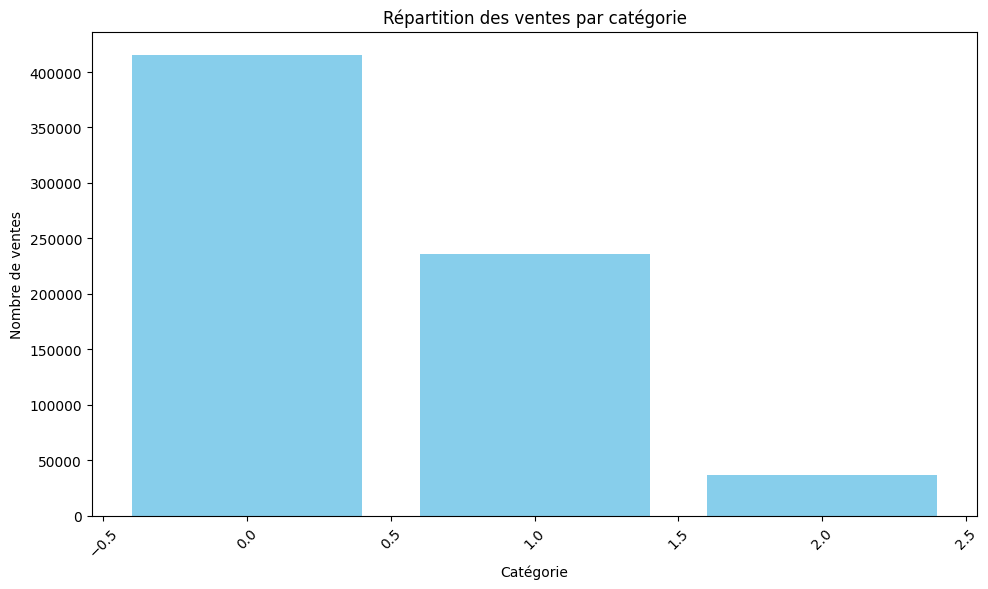

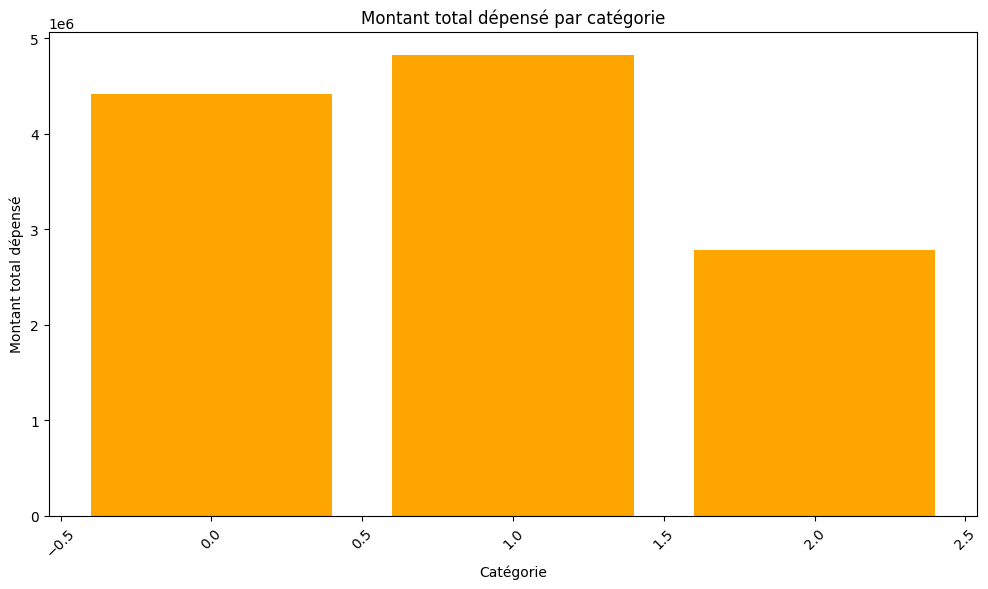

In [29]:

transactions_avec_cat = df_transactions.merge(df_products[['id_prod', 'categ', 'price']], on='id_prod', how='left')

transactions_avec_cat['montant'] = transactions_avec_cat['price']

# Regrouper par catégorie pour obtenir la répartition
repartition_ventes = transactions_avec_cat.groupby('categ').size().reset_index(name='nombre_ventes')

repartition_montant = transactions_avec_cat.groupby('categ')['montant'].sum().reset_index()

print("Répartition par nombre de ventes :")
print(repartition_ventes)

print("\nRépartition par montant total dépensé :")
print(repartition_montant)
import matplotlib.pyplot as plt

# Graphique pour la répartition par nombre de ventes
plt.figure(figsize=(10,6))
plt.bar(repartition_ventes['categ'], repartition_ventes['nombre_ventes'], color='skyblue')
plt.xlabel('Catégorie')
plt.ylabel('Nombre de ventes')
plt.title('Répartition des ventes par catégorie')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graphique pour la répartition par montant total dépensé
plt.figure(figsize=(10,6))
plt.bar(repartition_montant['categ'], repartition_montant['montant'], color='orange')
plt.xlabel('Catégorie')
plt.ylabel('Montant total dépensé')
plt.title('Montant total dépensé par catégorie')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### La courbe de Lorenz est une représentation graphique d'une variable au sein  d'une population

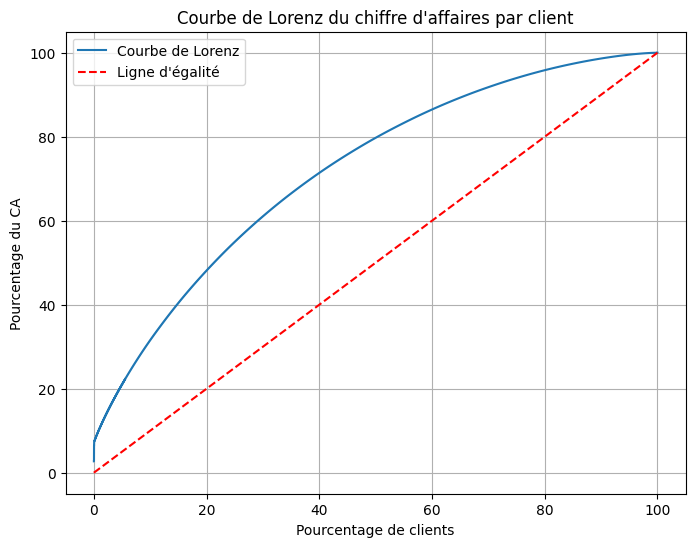

In [30]:


transaction_products = df_transactions.merge(df_products[['id_prod', 'price']], on='id_prod', how='left')


transaction_products['montant'] = transaction_products['price']


ca_par_client = transaction_products.groupby('client_id')['montant'].sum().reset_index()


ca_par_client = ca_par_client.sort_values(by='montant', ascending=False)


ca_par_client['ca_cumule'] = ca_par_client['montant'].cumsum()
total_ca = ca_par_client['montant'].sum()
ca_par_client['pourcentage_ca'] = 100 * ca_par_client['ca_cumule'] / total_ca

# Calculer la part cumulative des clients
ca_par_client['pourcentage_clients'] = 100 * (np.arange(len(ca_par_client)) + 1) / len(ca_par_client)

# Tracer la courbe de Lorenz
plt.figure(figsize=(8,6))
plt.plot(ca_par_client['pourcentage_clients'], ca_par_client['pourcentage_ca'], drawstyle='steps-post', label='Courbe de Lorenz')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Ligne d\'égalité')
plt.xlabel('Pourcentage de clients')
plt.ylabel('Pourcentage du CA')
plt.title('Courbe de Lorenz du chiffre d\'affaires par client')
plt.legend()
plt.grid(True)
plt.show()



#### La courbe montre une distribution très inégale du chiffre d’affaires : une minorité de clients génère la majorité des revenus, ce qui est fréquent dans de nombreux secteurs. 

### Les corrélations

In [31]:
import pandas as pd


df_customers['birth'] = pd.to_datetime(df_customers['birth'])

# Calculer l'âge en années
today = pd.to_datetime('today')

# La différence en jours
df_customers['age'] = (today - df_customers['birth']).dt.days 
print(df_customers)


     client_id sex                         birth    age
0       c_4410   f 1970-01-01 00:00:00.000001967  20336
1       c_7839   f 1970-01-01 00:00:00.000001975  20336
2       c_1699   f 1970-01-01 00:00:00.000001984  20336
3       c_5961   f 1970-01-01 00:00:00.000001962  20336
4       c_5320   m 1970-01-01 00:00:00.000001943  20336
...        ...  ..                           ...    ...
8616    c_7920   m 1970-01-01 00:00:00.000001956  20336
8617    c_7403   f 1970-01-01 00:00:00.000001970  20336
8618    c_5119   m 1970-01-01 00:00:00.000001974  20336
8619    c_5643   f 1970-01-01 00:00:00.000001968  20336
8620      c_84   f 1970-01-01 00:00:00.000001982  20336

[8621 rows x 4 columns]


In [32]:


# 2. Ajout de l'âge
df['birth'] = pd.to_datetime(df['birth'], format='%Y')
df['age'] = 2025 - df['birth'].dt.year  
print(" Genre ↔ Catégories des livres")
cross_tab1 = pd.crosstab(df['sex'], df['categ'], normalize='index')
print(cross_tab1)



print("Âge ↔ Montant total des achats")
age_price = df.groupby('age')['price'].sum().reset_index()
print(age_price)

print("Âge ↔ Fréquence d’achat (nb de sessions par client")
age_freq = df.groupby(['client_id', 'age'])['session_id'].nunique().reset_index(name='purchase_frequency')
print(age_freq.groupby('age')['purchase_frequency'].mean())

print("Âge ↔ Taille du panier moyen")
panier = df.groupby(['session_id', 'age'])['price'].sum().reset_index()
panier_moyen = panier.groupby('age')['price'].mean().reset_index(name='panier_moyen')
print(panier_moyen)

print("Âge ↔ Catégorie des livres")
cross_tab2 = pd.crosstab(df['age'], df['categ'], normalize='index')
print(cross_tab2)


 Genre ↔ Catégories des livres
categ         0         1         2
sex                                
f      0.601422  0.348145  0.050433
m      0.607109  0.337213  0.055678
Âge ↔ Montant total des achats
    age      price
0    21  616418.15
1    22  180680.89
2    23  186791.83
3    24  181233.57
4    25  167388.08
..  ...        ...
71   92    5477.83
72   93    5059.18
73   94    2815.45
74   95    4251.22
75   96    3249.84

[76 rows x 2 columns]
Âge ↔ Fréquence d’achat (nb de sessions par client
age
21    20.036613
22    18.034483
23    18.386207
24    19.904000
25    18.205882
        ...    
92    29.625000
93    34.500000
94    24.000000
95    37.750000
96    45.000000
Name: purchase_frequency, Length: 76, dtype: float64
Âge ↔ Taille du panier moyen
    age  panier_moyen
0    21     70.399515
1    22     69.094031
2    23     70.064452
3    24     72.843075
4    25     67.604233
..  ...           ...
71   92     23.113207
72   93     24.440483
73   94     29.327604
74   95   

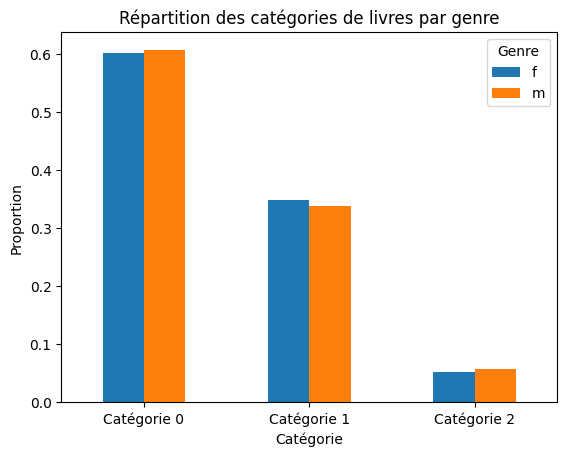

In [33]:
import matplotlib.pyplot as plt

# Données
genre_categ = pd.DataFrame({
    'f': [0.601422, 0.348145, 0.050433],
    'm': [0.607109, 0.337213, 0.055678]
}, index=['Catégorie 0', 'Catégorie 1', 'Catégorie 2'])

# Tracé
genre_categ.plot(kind='bar', rot=0)
plt.title("Répartition des catégories de livres par genre")
plt.ylabel("Proportion")
plt.xlabel("Catégorie")
plt.legend(title="Genre")
plt.show()


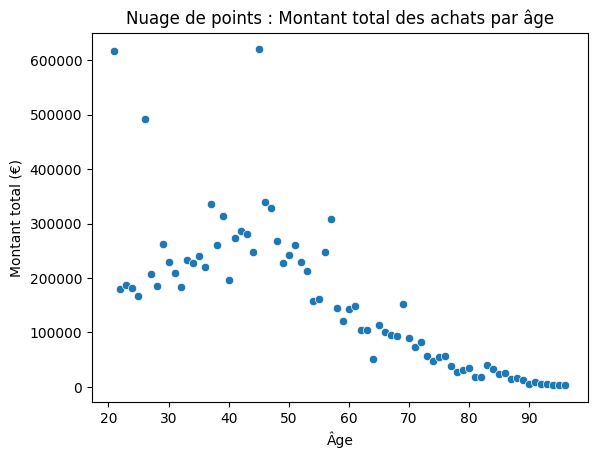

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Supposons que votre DataFrame s'appelle age_price avec les colonnes 'age' et 'price'
sns.scatterplot(data=age_price, x='age', y='price')
plt.title("Nuage de points : Montant total des achats par âge")
plt.ylabel("Montant total (€)")
plt.xlabel("Âge")
plt.show()


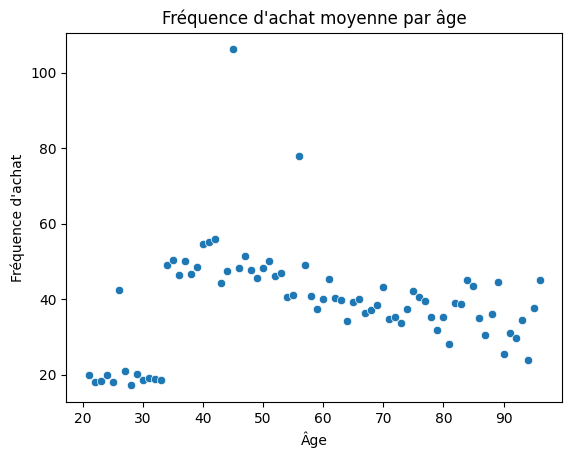

In [35]:
df_freq = age_freq.groupby('age')['purchase_frequency'].mean().reset_index()

sns.scatterplot(data=df_freq, x='age', y='purchase_frequency')
plt.title("Fréquence d'achat moyenne par âge")
plt.ylabel("Fréquence d'achat")
plt.xlabel("Âge")
plt.show()


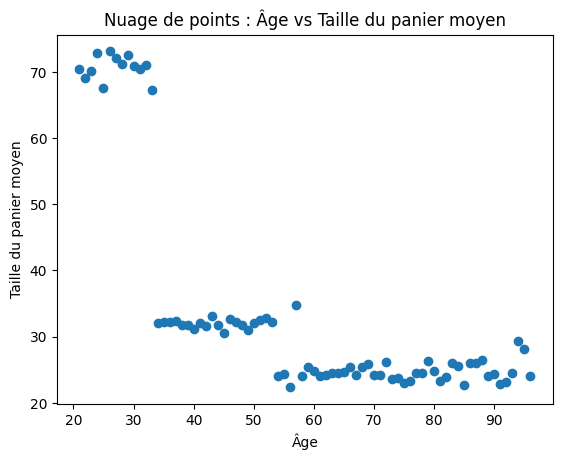

In [36]:
plt.scatter(panier_moyen['age'], panier_moyen['panier_moyen'])
plt.xlabel("Âge")
plt.ylabel("Taille du panier moyen")
plt.title("Nuage de points : Âge vs Taille du panier moyen")
plt.show()


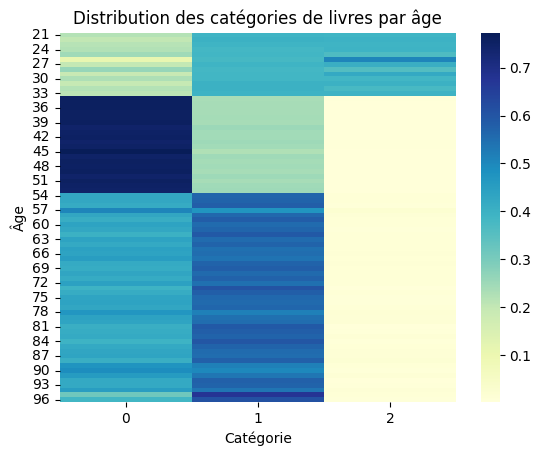

In [37]:
sns.heatmap(cross_tab2, cmap="YlGnBu", annot=False)
plt.title("Distribution des catégories de livres par âge")
plt.xlabel("Catégorie")
plt.ylabel("Âge")
plt.show()


### Différents tests éffectués

#### le test chi2 permet d'évaluer la corrélation entre deux variables catégorielles

#### Le coefficient de corrélation de pearson permet de mesurer une relation entre deux variables numériques continues

In [38]:
# Âge ↔ montant total
pearson1 = age_price['age'].corr(age_price['price'])
spearman1 = age_price['age'].corr(age_price['price'], method='spearman')


# Âge ↔ fréquence d’achat
spearman2 = df_freq['age'].corr(df_freq['purchase_frequency'], method='spearman')

# Âge ↔ panier moyen
spearman3 = panier_moyen['age'].corr(panier_moyen['panier_moyen'],method='spearman')

print("Corrélation avec pearson(âge ↔ montant total):", pearson1)
print("Corrélation avec spearman(âge ↔ montant total):", spearman1)
print("Corrélation (âge ↔ fréquence d'achat):", spearman2)
print("Corrélation (âge ↔ panier moyen):", spearman3)


Corrélation avec pearson(âge ↔ montant total): -0.7796292816296743
Corrélation avec spearman(âge ↔ montant total): -0.8583732057416268
Corrélation (âge ↔ fréquence d'achat): -0.060642929891573126
Corrélation (âge ↔ panier moyen): -0.7746001367053998


In [39]:
from scipy.stats import chi2_contingency

# Tableau brut (sans proportions)
genre_categ_counts = pd.crosstab(df['sex'], df['categ'])

# Test chi²
chi2, p, dof, expected = chi2_contingency(genre_categ_counts)
print("Corrélation entre le genre et la catégorie")
print("Chi² =", chi2, " | p-value =", p)


Corrélation entre le genre et la catégorie
Chi² = 158.25417617304882  | p-value = 4.3205822283997063e-35


In [40]:
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 45, 60, 75, 100], labels=['18-30','31-45','46-60','61-75','76+'])

contingency = pd.crosstab(df['age_group'], df['categ'])

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency)
print("Corrélation entre l'age et la catégorie")
print("Chi² =", chi2, "| p-value =", p)


Corrélation entre l'age et la catégorie
Chi² = 228703.1597170802 | p-value = 0.0


In [42]:
import pandas as pd
import statsmodels.api as sm 
from statsmodels.formula.api import ols 

df['categ'] = df['categ'].astype('category')

# Modèle ANOVA
model = ols('age ~ C(categ)', data=df).fit()


anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                sum_sq        df             F  PR(>F)
C(categ)  1.477154e+07       2.0  45120.035536     0.0
Residual  1.125430e+08  687531.0           NaN     NaN


In [ ]:
from scipy.stats import shapiro


stat, p_value = shapiro(age_price['age'])
print(f'Shapiro-Wilk: stat={stat}, p={p_value}')
# p < 0.05 donc on rejette l'hypothese suivant laquelle l age suit une loi normale


Shapiro-Wilk: stat=0.9549230726696206, p=0.008752885621051844
    age      price
0    21  616418.15
1    22  180680.89
2    23  186791.83
3    24  181233.57
4    25  167388.08
..  ...        ...
71   92    5477.83
72   93    5059.18
73   94    2815.45
74   95    4251.22
75   96    3249.84

[76 rows x 2 columns]


In [47]:
from scipy.stats import kruskal


categories = df['categ'].unique()
data = [df.loc[df['categ'] == cat, 'age'] for cat in categories]

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data)
print(f"Kruskal-Wallis: stat={stat:.4f}, p={p_value:.4f}")




Kruskal-Wallis: stat=78458.4384, p=0.0000


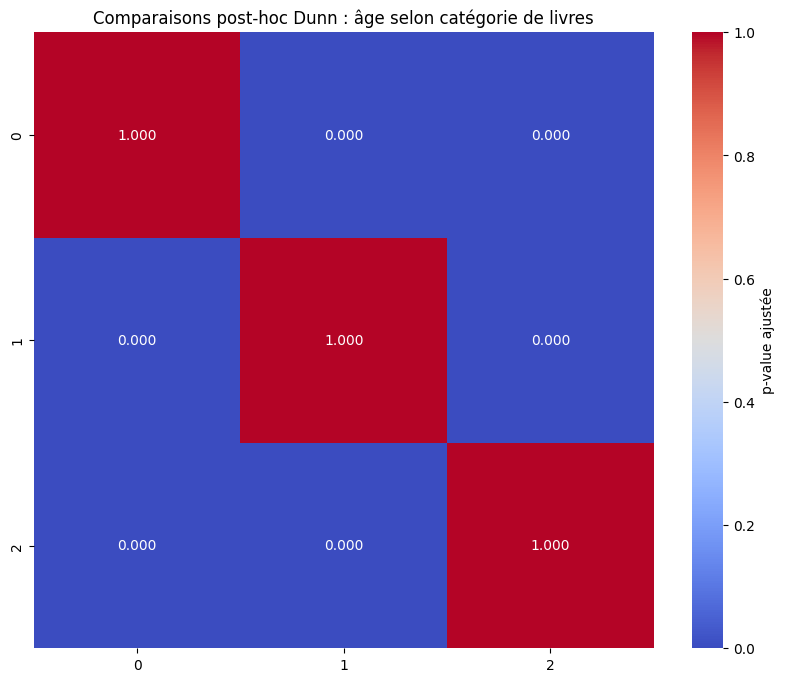

In [ ]:
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# Test post-hoc de Dunn avec correction Bonferroni
posthoc = sp.posthoc_dunn(df, val_col='age', group_col='categ', p_adjust='bonferroni')


plt.figure(figsize=(10, 8))
sns.heatmap(posthoc, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={'label': 'p-value ajustée'})
plt.title("Comparaisons post-hoc Dunn : âge selon catégorie de livres")
plt.show()
